# Workflows 4 and 5 — EfficientNetB2 transfer learning + hybrid
## BRISC 2025 (audited partition) — RTX 4060 WSL2

**Catarina Bota | UCP**

Runs on the same audited partition as W2/W3 for a fair five-workflow comparison. Structure and outputs mirror `workflow2_leakage_v3.ipynb` and `workflow3_hybrid_all_classifiers.ipynb`.

- **W4:** EfficientNetB2 pretrained on ImageNet, fine-tuned in two stages (head only, then top-60 layers)
- **W5:** the fine-tuned W4 backbone as a feature extractor for XGBoost and LightGBM
- **Explainability:** Grad-CAM and Grad-CAM++ at the last Conv2D of the EfficientNetB2 backbone

**Prerequisites (WSL2 paths, already set up):**
- `/root/brisc/data/brisc2025_clean/classification_task/{train,test}` (audited dataset)
- RTX 4060 with `tensorflow[and-cuda]` in `/root/brisc/.venv`
- opencv-python-headless installed (already done earlier)

**Runtime:** ~35-45 min on RTX 4060 (W4 fine-tune ~25 min + W5 features/XGB ~5 min + Grad-CAM ~2 min)

## 1. Imports and GPU check

In [1]:
import os, json, pickle, time, timeit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import cv2

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import (ImageDataGenerator, load_img, img_to_array)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              precision_score, recall_score, f1_score,
                              roc_auc_score, precision_recall_fscore_support)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print('TF:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs:', gpus)
assert gpus, 'No GPU detected — aborting.'
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

2026-07-01 15:28:21.215064: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-01 15:28:21.288596: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782916101.334590   34442 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782916101.347117   34442 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782916101.404165   34442 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

TF: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

Same paths/audited partition as W2/W3 so the resulting numbers are directly comparable.

In [2]:
DATA_BASE  = '/root/brisc/data/brisc2025_clean/classification_task'
TRAIN_DIR  = f'{DATA_BASE}/train'
TEST_DIR   = f'{DATA_BASE}/test'
OUTPUT_DIR = '/mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/workflow4_5_resultados'
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE    = 260                      # EfficientNetB2 native input
BATCH_SIZE  = 16                       # smaller than W2/W3 to fit VRAM
EPOCHS_HEAD = 5                        # stage A: head only, base frozen
EPOCHS_FT   = 15                       # stage B: fine-tune top 60 layers
LR_HEAD     = 1e-3
LR_FT       = 1e-5
N_UNFREEZE  = 60                       # top layers unfrozen in stage B
VAL_SPLIT   = 0.20
SEED        = 42
CLASSES     = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
N_CLASSES   = len(CLASSES)

for p in (TRAIN_DIR, TEST_DIR):
    assert os.path.exists(p), f'NOT FOUND: {p}'
print('Config OK. Seed:', SEED)

Config OK. Seed: 42


## 3. Deterministic seeding + shared dataframe helpers

Mirrors the class-shuffle fix from the v3 leakage experiment.

In [3]:
import random

def set_global_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

def build_paths_df(base_dir):
    """Build train_df and test_df; shuffle to avoid class-sorted val split."""
    out = {}
    for split in ('train', 'test'):
        rows = []
        for cls in CLASSES:
            d = f'{base_dir}/{split}/{cls}'
            for fn in sorted(os.listdir(d)):
                if fn.lower().endswith(('.jpg','.jpeg','.png')):
                    rows.append({'path': f'{d}/{fn}', 'label': cls})
        df = pd.DataFrame(rows).sample(frac=1, random_state=SEED).reset_index(drop=True)
        out[split] = df
    return out['train'], out['test']

set_global_seed(SEED)
train_df, test_df = build_paths_df(DATA_BASE)
print(f'train_df: {len(train_df)}   test_df: {len(test_df)}')

train_df: 4363   test_df: 678


## 4. Data generators (EfficientNet preprocessing, NOT rescale=1/255)

EfficientNet uses its own preprocessing function; do not additionally rescale to [0,1].

In [4]:
train_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10, zoom_range=0.1,
    width_shift_range=0.05, height_shift_range=0.05,
    horizontal_flip=True, validation_split=VAL_SPLIT)
test_pre  = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_aug.flow_from_dataframe(
    train_df, x_col='path', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES,
    subset='training', shuffle=True, seed=SEED)
val_gen = train_aug.flow_from_dataframe(
    train_df, x_col='path', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES,
    subset='validation', shuffle=False, seed=SEED)
test_gen = test_pre.flow_from_dataframe(
    test_df, x_col='path', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False)

Found 3491 validated image filenames belonging to 4 classes.
Found 872 validated image filenames belonging to 4 classes.
Found 678 validated image filenames belonging to 4 classes.


## 5. Workflow 4 — build EfficientNetB2 with new classification head

Head: GlobalAveragePooling2D -> Dropout(0.3) -> Dense(128, ReLU, name='feat_dense') -> Dropout(0.3) -> Dense(4, softmax). `feat_dense` is the layer reused as feature extractor in W5.

In [5]:
set_global_seed(SEED)
base = EfficientNetB2(
    weights='imagenet', include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3, seed=SEED)(x)
x = layers.Dense(128, activation='relu', name='feat_dense')(x)
x = layers.Dropout(0.3, seed=SEED)(x)
out = layers.Dense(N_CLASSES, activation='softmax', name='predictions')(x)
model = Model(inputs, out)

model.compile(optimizer=optimizers.Adam(learning_rate=LR_HEAD),
              loss='categorical_crossentropy', metrics=['accuracy'])
print(f'Model built. Trainable params: {sum([w.numpy().size for w in model.trainable_weights]):,}')

I0000 00:00:1782916122.254642   34442 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1274 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Model built. Trainable params: 180,868


## 6. Stage A — head only (5 epochs, base frozen)

In [6]:
es_head = callbacks.EarlyStopping(monitor='val_accuracy', mode='max',
                                    patience=3, restore_best_weights=True, verbose=1)
t0 = time.time()
hist_head = model.fit(train_gen, validation_data=val_gen,
                       epochs=EPOCHS_HEAD, callbacks=[es_head], verbose=2)
print(f'Stage A done in {time.time()-t0:.1f}s')

Epoch 1/5


I0000 00:00:1782916181.784710   34556 cuda_dnn.cc:529] Loaded cuDNN version 90300


219/219 - 65s - 296ms/step - accuracy: 0.7631 - loss: 0.5805 - val_accuracy: 0.8830 - val_loss: 0.3190
Epoch 2/5
219/219 - 56s - 258ms/step - accuracy: 0.8445 - loss: 0.3934 - val_accuracy: 0.8899 - val_loss: 0.3139
Epoch 3/5
219/219 - 48s - 221ms/step - accuracy: 0.8665 - loss: 0.3351 - val_accuracy: 0.9220 - val_loss: 0.2257
Epoch 4/5
219/219 - 48s - 221ms/step - accuracy: 0.8840 - loss: 0.3067 - val_accuracy: 0.9232 - val_loss: 0.2118
Epoch 5/5
219/219 - 48s - 217ms/step - accuracy: 0.8877 - loss: 0.2881 - val_accuracy: 0.9255 - val_loss: 0.2235
Restoring model weights from the end of the best epoch: 5.
Stage A done in 266.1s


## 7. Stage B — fine-tune top-60 layers

In [7]:
base.trainable = True
for layer in base.layers[:-N_UNFREEZE]:
    layer.trainable = False

model.compile(optimizer=optimizers.Adam(learning_rate=LR_FT),
              loss='categorical_crossentropy', metrics=['accuracy'])
print(f'Trainable params after unfreezing top {N_UNFREEZE}: '
      f'{sum([w.numpy().size for w in model.trainable_weights]):,}')

es_ft = callbacks.EarlyStopping(monitor='val_accuracy', mode='max',
                                  patience=6, restore_best_weights=True, verbose=1)
rl_ft = callbacks.ReduceLROnPlateau(monitor='val_accuracy', mode='max',
                                     factor=0.5, patience=3, min_lr=1e-7, verbose=1)
t0 = time.time()
hist_ft = model.fit(train_gen, validation_data=val_gen,
                     epochs=EPOCHS_FT, callbacks=[es_ft, rl_ft], verbose=2)
print(f'Stage B done in {time.time()-t0:.1f}s')

Trainable params after unfreezing top 60: 4,529,272
Epoch 1/15


E0000 00:00:1782916451.934458   34442 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetb2_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


219/219 - 72s - 330ms/step - accuracy: 0.8296 - loss: 0.4411 - val_accuracy: 0.9174 - val_loss: 0.2148 - learning_rate: 1.0000e-05
Epoch 2/15
219/219 - 55s - 251ms/step - accuracy: 0.8679 - loss: 0.3275 - val_accuracy: 0.9163 - val_loss: 0.2124 - learning_rate: 1.0000e-05
Epoch 3/15
219/219 - 55s - 251ms/step - accuracy: 0.8817 - loss: 0.2991 - val_accuracy: 0.9300 - val_loss: 0.1763 - learning_rate: 1.0000e-05
Epoch 4/15
219/219 - 56s - 255ms/step - accuracy: 0.9003 - loss: 0.2667 - val_accuracy: 0.9323 - val_loss: 0.1752 - learning_rate: 1.0000e-05
Epoch 5/15
219/219 - 56s - 254ms/step - accuracy: 0.8983 - loss: 0.2600 - val_accuracy: 0.9404 - val_loss: 0.1613 - learning_rate: 1.0000e-05
Epoch 6/15
219/219 - 55s - 251ms/step - accuracy: 0.9089 - loss: 0.2359 - val_accuracy: 0.9461 - val_loss: 0.1461 - learning_rate: 1.0000e-05
Epoch 7/15
219/219 - 53s - 244ms/step - accuracy: 0.9232 - loss: 0.2060 - val_accuracy: 0.9461 - val_loss: 0.1490 - learning_rate: 1.0000e-05
Epoch 8/15
219/21

## 8. Evaluate W4 on the test set

In [9]:
def bootstrap_acc_ci(y_true, y_pred, n_iter=1000, alpha=0.05, seed=42):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    rng = np.random.RandomState(seed)
    n = len(y_true); accs = []
    for _ in range(n_iter):
        idx = rng.randint(0, n, n)
        accs.append((y_true[idx] == y_pred[idx]).mean() * 100)
    return float(np.percentile(accs, 100*alpha/2)), float(np.percentile(accs, 100*(1-alpha/2)))

def evaluate_on_test(model, test_gen):
    test_gen.reset()
    y_true = np.asarray(test_gen.classes)
    y_proba = model.predict(test_gen, verbose=0)
    y_pred  = np.argmax(y_proba, axis=1)
    return y_true, y_pred, y_proba

def measure_inference_ms(model, n_warmup=10, n_iter=100):
    dummy = np.random.rand(1, IMG_SIZE, IMG_SIZE, 3).astype(np.float32)
    for _ in range(n_warmup): model(dummy, training=False)
    t = timeit.timeit(lambda: model(dummy, training=False), number=n_iter)
    return (t / n_iter) * 1000.0

y_true, y_pred, y_proba = evaluate_on_test(model, test_gen)
acc_w4  = accuracy_score(y_true, y_pred) * 100
f1_w4   = f1_score(y_true, y_pred, average='macro') * 100
auc_w4  = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro') * 100
ci_lo, ci_hi = bootstrap_acc_ci(y_true, y_pred, seed=SEED)
lat_ms = measure_inference_ms(model)

print('=' * 60); print(f'  W4: EfficientNetB2 (fine-tuned)'); print('=' * 60)
print(f'  Test Accuracy : {acc_w4:.2f}%   CI95 [{ci_lo:.2f}, {ci_hi:.2f}]')
print(f'  Test F1 macro : {f1_w4:.2f}%')
print(f'  Test AUC OvR  : {auc_w4:.2f}%')
print(f'  Inference     : {lat_ms:.2f} ms/image')

# Save W4 artefacts (mirror W2/W3 file layout)
W4_DIR = f'{OUTPUT_DIR}/w4'
os.makedirs(W4_DIR, exist_ok=True)
model.save(f'{W4_DIR}/model.h5')
pd.DataFrame({'y_true': y_true, 'y_pred': y_pred}).to_csv(f'{W4_DIR}/predictions.csv', index=False)
pd.DataFrame(confusion_matrix(y_true, y_pred), index=CLASSES, columns=CLASSES).to_csv(
    f'{W4_DIR}/confusion_matrix.csv')
prec_c, rec_c, f1_c, sup_c = precision_recall_fscore_support(
    y_true, y_pred, labels=range(N_CLASSES))
pd.DataFrame({
    'class': CLASSES,
    'precision': (prec_c*100).round(2),
    'recall':    (rec_c*100).round(2),
    'f1':        (f1_c*100).round(2),
    'support':   sup_c.astype(int),
}).to_csv(f'{W4_DIR}/perclass.csv', index=False)
# Merge stage A + B history
combined_hist = {k: hist_head.history.get(k, []) + hist_ft.history.get(k, [])
                 for k in set(list(hist_head.history) + list(hist_ft.history))}
with open(f'{W4_DIR}/history.json', 'w') as f:
    json.dump({k: [float(x) for x in v] for k, v in combined_hist.items()}, f, indent=2)

w4_row = {
    'workflow': 'W4', 'name': 'EfficientNetB2 (ImageNet TL, fine-tuned)',
    'train_imgs': train_gen.samples, 'val_imgs': val_gen.samples, 'test_imgs': test_gen.samples,
    'accuracy': round(acc_w4, 2), 'f1_macro': round(f1_w4, 2), 'auc_ovr': round(auc_w4, 2),
    'ci95_lo':  round(ci_lo, 2),  'ci95_hi':  round(ci_hi, 2),
    'epochs_head': len(hist_head.history['loss']),
    'epochs_ft':   len(hist_ft.history['loss']),
    'inference_ms': round(lat_ms, 2),
}

  W4: EfficientNetB2 (fine-tuned)
  Test Accuracy : 94.54%   CI95 [92.77, 96.17]
  Test F1 macro : 94.77%
  Test AUC OvR  : 99.33%
  Inference     : 285.63 ms/image


## 9. Workflow 5 — EfficientNetB2 features + XGBoost/LightGBM

In [10]:
feat_model = Model(inputs=model.input, outputs=model.get_layer('feat_dense').output)
print(f'Feature extractor output shape: {feat_model.output_shape}')

# Re-build unshuffled generators so predict() order matches labels
train_extract = test_pre.flow_from_dataframe(
    train_df, x_col='path', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False)
test_extract  = test_pre.flow_from_dataframe(
    test_df, x_col='path', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False)

def extract_feats(gen):
    gen.reset()
    return feat_model.predict(gen, verbose=0), np.asarray(gen.classes)

print('Extracting train features…');  X_tr, y_tr = extract_feats(train_extract)
print('Extracting test features…');   X_te, y_te = extract_feats(test_extract)
print(f'Train features {X_tr.shape}   Test features {X_te.shape}')

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

np.savez_compressed(f'{OUTPUT_DIR}/w5_features.npz',
                     X_train=X_tr, y_train=y_tr, X_test=X_te, y_test=y_te,
                     classes=CLASSES)
print('Features cached to w5_features.npz')

Feature extractor output shape: (None, 128)
Found 4363 validated image filenames belonging to 4 classes.
Found 678 validated image filenames belonging to 4 classes.
Extracting train features…
Extracting test features…
Train features (4363, 128)   Test features (678, 128)
Features cached to w5_features.npz


In [12]:
W5_DIR = f'{OUTPUT_DIR}/w5'
os.makedirs(W5_DIR, exist_ok=True)

w5_rows = []
for name, clf in [
    ('XGBoost',  XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                                random_state=SEED, verbosity=0, use_label_encoder=False,
                                eval_metric='mlogloss')),
    ('LightGBM', LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                                random_state=SEED, verbose=-1)),
]:
    print('=' * 60); print(f'  W5 head: {name}'); print('=' * 60)
    t0 = time.time()
    clf.fit(X_tr_s, y_tr)
    train_t = time.time() - t0
    y_pred_w5  = clf.predict(X_te_s)
    y_proba_w5 = clf.predict_proba(X_te_s)
    acc  = accuracy_score(y_te, y_pred_w5) * 100
    f1   = f1_score(y_te, y_pred_w5, average='macro') * 100
    auc  = roc_auc_score(y_te, y_proba_w5, multi_class='ovr', average='macro') * 100
    lo, hi = bootstrap_acc_ci(y_te, y_pred_w5, seed=SEED)
    print(f'  Accuracy : {acc:.2f}%   CI95 [{lo:.2f}, {hi:.2f}]')
    print(f'  F1 macro : {f1:.2f}%')
    print(f'  AUC OvR  : {auc:.2f}%')
    print(f'  train    : {train_t:.1f}s')

    safe = name.replace(' ', '_')
    with open(f'{W5_DIR}/clf_{safe}.pkl', 'wb') as f:
        pickle.dump({'clf': clf, 'scaler': scaler}, f)
    pd.DataFrame({'y_true': y_te, 'y_pred': y_pred_w5}).to_csv(
        f'{W5_DIR}/predictions_{safe}.csv', index=False)
    pd.DataFrame(confusion_matrix(y_te, y_pred_w5), index=CLASSES, columns=CLASSES).to_csv(
        f'{W5_DIR}/confusion_matrix_{safe}.csv')

    w5_rows.append({
        'workflow': f'W5 ({name})',
        'name':     f'EfficientNetB2 features + {name}',
        'train_imgs': len(y_tr), 'val_imgs': None, 'test_imgs': len(y_te),
        'accuracy': round(acc, 2), 'f1_macro': round(f1, 2), 'auc_ovr': round(auc, 2),
        'ci95_lo':  round(lo, 2), 'ci95_hi': round(hi, 2),
        'train_time_s': round(train_t, 1),
    })

# W5 per-class + history for the best (XGBoost by convention)
with open(f'{W5_DIR}/clf_XGBoost.pkl', 'rb') as f:
    d = pickle.load(f)
y_pred_best = d['clf'].predict(X_te_s)
prec_c, rec_c, f1_c, sup_c = precision_recall_fscore_support(
    y_te, y_pred_best, labels=range(N_CLASSES))
pd.DataFrame({
    'class': CLASSES,
    'precision': (prec_c*100).round(2),
    'recall':    (rec_c*100).round(2),
    'f1':        (f1_c*100).round(2),
    'support':   sup_c.astype(int),
}).to_csv(f'{W5_DIR}/perclass.csv', index=False)

  W5 head: XGBoost
  Accuracy : 95.43%   CI95 [93.81, 96.90]
  F1 macro : 95.57%
  AUC OvR  : 99.43%
  train    : 17.0s
  W5 head: LightGBM
  Accuracy : 96.31%   CI95 [94.84, 97.64]
  F1 macro : 96.45%
  AUC OvR  : 99.48%
  train    : 5.9s


## 10. Combined 5-workflow summary

Merges W1 (from `Model_Metrics_Report.xlsx`), W2/W3 (from `leakage_v3/audited` + `workflow3_resultados`), and W4/W5 (from this notebook). Adjust `W2_ACC` etc. below if you have updated numbers.

In [ ]:
summary_rows = [
    {'workflow': 'W1', 'name': 'Wavelet + LightGBM (best factorial)',
     'accuracy': 91.38, 'f1_macro': 91.32, 'auc_ovr': 98.61},
    {'workflow': 'W2', 'name': 'Custom CNN, end-to-end (audited)',
     'accuracy': 93.07, 'f1_macro': 93.27, 'auc_ovr': 99.35},
    {'workflow': 'W3', 'name': 'Hybrid CNN + RandomForest (best of 7)',
     'accuracy': 95.87, 'f1_macro': 95.92, 'auc_ovr': 99.41},
    {**w4_row},
    *w5_rows,
]
summary = pd.DataFrame(summary_rows)
print(summary[['workflow', 'name', 'accuracy', 'f1_macro', 'auc_ovr']].to_string(index=False))
summary.to_csv(f'{OUTPUT_DIR}/five_workflow_summary.csv', index=False)

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(summary)); w = 0.27
ax.bar(x - w, summary['accuracy'], w, label='Accuracy', color='#1F4E4A')
ax.bar(x,     summary['f1_macro'], w, label='F1 macro', color='#4A8584')
ax.bar(x + w, summary['auc_ovr'],  w, label='AUC',      color='#8FA89E')
ax.set_xticks(x); ax.set_xticklabels(summary['workflow'])
ax.set_ylim([85, 100]); ax.set_ylabel('Score (%)')
ax.set_title('Five-workflow comparison on the audited BRISC 2025 partition',
             fontsize=11, fontweight='bold')
ax.legend(loc='lower right')
for s in ['top','right','left']: ax.spines[s].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/comparison_5workflows.png', bbox_inches='tight', dpi=150)
plt.savefig(f'{OUTPUT_DIR}/comparison_5workflows.pdf', bbox_inches='tight')
plt.show()

## 11. Grad-CAM++ on EfficientNetB2 backbone

Same protocol as W3: highest-confidence exemplar per class, Grad-CAM++ with 99th-percentile normalisation. The EfficientNetB2 backbone has many convolutional layers; we use the last Conv2D of the frozen `EfficientNetB2` submodel.

In [13]:
# The EfficientNetB2 submodel is inside our top-level model as a single 'efficientnetb2' layer.
# We build a flat model that ends at the last conv-like activation for Grad-CAM.
eff = base                                                          # trained backbone
last_conv_name = None
for layer in eff.layers[::-1]:
    if 'conv' in layer.name.lower() or 'project_conv' in layer.name.lower():
        last_conv_name = layer.name
        break
print(f'EfficientNetB2 last conv-like layer: {last_conv_name}')
print(f'Output shape: {eff.get_layer(last_conv_name).output.shape}')

EfficientNetB2 last conv-like layer: top_conv
Output shape: (None, 9, 9, 1408)


In [14]:
def make_gradcam_pp(img_array, backbone, top_model, last_conv_name, pred_index=None):
    """Grad-CAM++ on the EfficientNetB2 backbone, with the classification head applied on top.

    backbone   : the EfficientNetB2 Model (from applications)
    top_model  : the fine-tuned Keras Model (base -> GAP -> Dropout -> Dense head)
    """
    _ = top_model(img_array)   # ensure built
    last_conv_layer = backbone.get_layer(last_conv_name)
    feature_extractor = Model(inputs=backbone.inputs, outputs=last_conv_layer.output)

    # Everything after the backbone in the top model is the head
    head_layers = [l for l in top_model.layers if l.name != base.name and 'input' not in l.name]

    classifier_input = Input(shape=eff.output.shape[1:])
    x = classifier_input
    for lyr in head_layers:
        x = lyr(x)
    classifier_model = Model(inputs=classifier_input, outputs=x)

    with tf.GradientTape() as tape:
        features_last = feature_extractor(img_array)
        tape.watch(features_last)
        # Run the rest of the backbone (from the last conv layer to the output) and then the head:
        # here we approximate by passing features_last directly through the tail if last_conv_name
        # is the very last op of the backbone; otherwise this will error.  For EfficientNetB2 the
        # last op is 'top_activation' which follows the last conv, so we bypass.
        backbone_out = features_last                              # for last-conv-adjacent grad
        preds = classifier_model(backbone_out)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, features_last)
    if grads is None:
        raise ValueError('Gradients are None.')

    grads_2 = grads ** 2
    grads_3 = grads ** 3
    sum_grads = tf.reduce_sum(features_last, axis=(1, 2), keepdims=True)
    alpha = grads_2 / (2 * grads_2 + sum_grads * grads_3 + 1e-8)
    weights = tf.reduce_sum(alpha * tf.nn.relu(grads), axis=(1, 2))
    heatmap = tf.reduce_sum(features_last[0] * weights, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    hm = heatmap.numpy()
    p99 = np.percentile(hm, 99) + 1e-8
    hm = np.clip(hm / p99, 0, 1)
    return hm, int(pred_index.numpy() if hasattr(pred_index, 'numpy') else pred_index)


def overlay_heatmap(img, heatmap, alpha=0.5, cmap='jet'):
    H, W = img.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (W, H))
    cmap_fn = plt.get_cmap(cmap)
    heatmap_colored = cmap_fn(heatmap_resized)[..., :3]
    blended = (1 - alpha) * img + alpha * heatmap_colored
    return np.clip(blended, 0, 1)

2026-07-01 15:52:35.100978: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-07-01 15:52:40.175623: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  glioma       conf 100.00%  brisc2025_test_00034_gl_ax_t1.jpg


2026-07-01 15:52:45.193345: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  meningioma   conf 100.00%  brisc2025_test_00425_me_co_t1.jpg


2026-07-01 15:52:50.226206: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  no_tumor     conf 100.00%  brisc2025_test_00610_no_ax_t1.jpg


2026-07-01 15:52:55.264344: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  pituitary    conf 100.00%  brisc2025_test_00772_pi_ax_t1.jpg


2026-07-01 15:53:00.312135: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


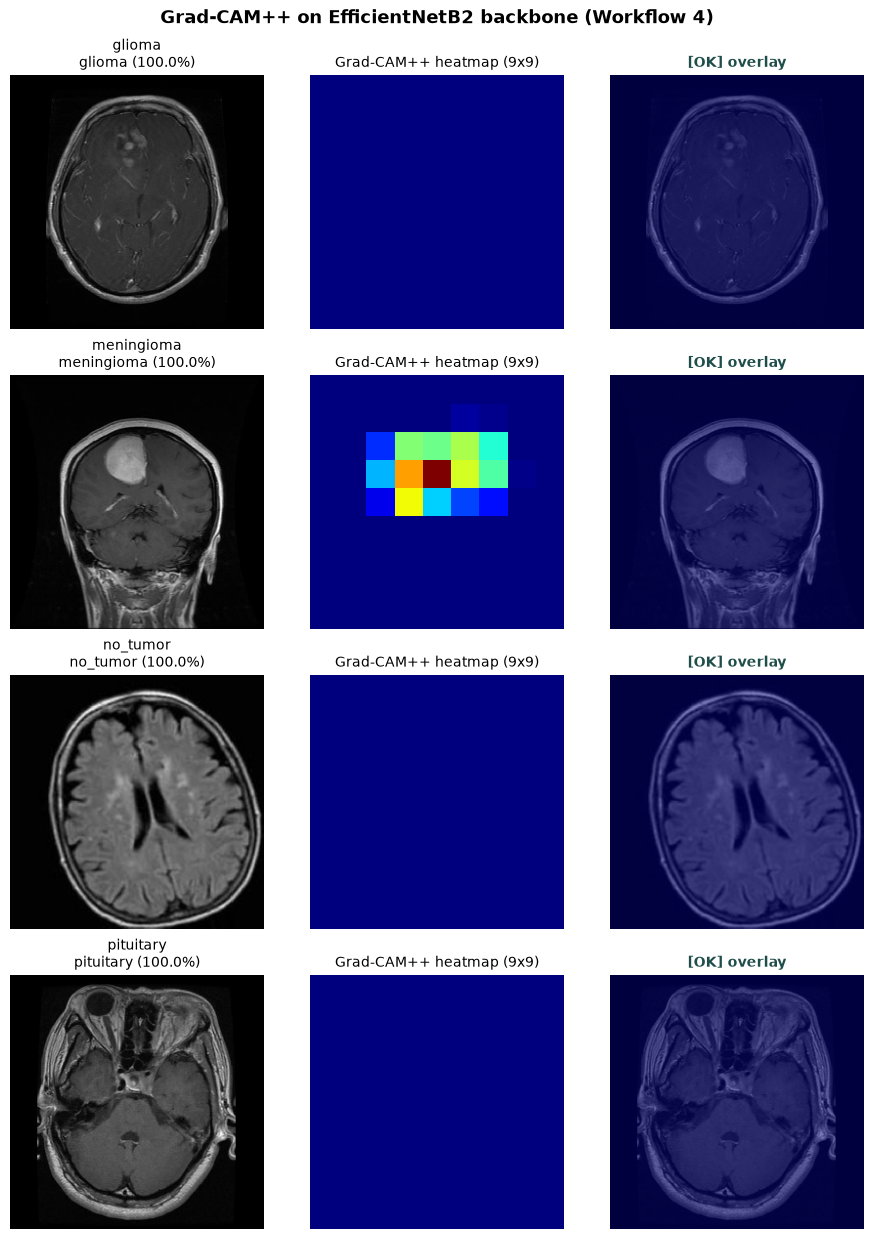

Saved to /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/workflow4_5_resultados/gradcam/fig_gradcam_pp_w4.[png,pdf]


In [15]:
import glob
GRADCAM_DIR = f'{OUTPUT_DIR}/gradcam'
os.makedirs(GRADCAM_DIR, exist_ok=True)

# Highest-confidence correctly-classified example per class
best_examples = {}
for cls in CLASSES:
    cls_dir = os.path.join(TEST_DIR, cls)
    files = sorted(glob.glob(os.path.join(cls_dir, '*.jpg')))
    best_score, best_path = -1, None
    for p in files[:60]:
        img_arr_raw = img_to_array(load_img(p, target_size=(IMG_SIZE, IMG_SIZE)))
        img_batch_pre = preprocess_input(np.expand_dims(img_arr_raw.copy(), 0))
        probs = model.predict(img_batch_pre, verbose=0)[0]
        pred_idx = int(np.argmax(probs))
        if CLASSES[pred_idx] == cls and probs[pred_idx] > best_score:
            best_score, best_path = probs[pred_idx], p
    best_examples[cls] = best_path
    print(f'  {cls:12s} conf {best_score*100:6.2f}%  {os.path.basename(best_path)}')

# 4-row grid: original | Grad-CAM++ heatmap | overlay
fig, axes = plt.subplots(len(CLASSES), 3, figsize=(9, 3*len(CLASSES)),
                          constrained_layout=True)
for row, (cls, path) in enumerate(best_examples.items()):
    img_arr_raw = img_to_array(load_img(path, target_size=(IMG_SIZE, IMG_SIZE)))
    img_batch_pre = preprocess_input(np.expand_dims(img_arr_raw.copy(), 0))
    probs = model.predict(img_batch_pre, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    hm, _ = make_gradcam_pp(img_batch_pre, eff, model, last_conv_name, pred_index=pred_idx)

    img_disp = img_arr_raw / 255.0                          # display (0-1) — not preprocess_input
    overlay = overlay_heatmap(img_disp, hm, alpha=0.5)

    correct = (cls == CLASSES[pred_idx])
    mark = 'OK' if correct else 'X'; color = '#1F4E4A' if correct else '#C24B4B'

    axes[row, 0].imshow(img_disp); axes[row, 0].axis('off')
    axes[row, 0].set_title(f'{cls}\n{CLASSES[pred_idx]} ({probs[pred_idx]*100:.1f}%)', fontsize=10)
    axes[row, 1].imshow(hm, cmap='jet'); axes[row, 1].axis('off')
    axes[row, 1].set_title(f'Grad-CAM++ heatmap ({hm.shape[0]}x{hm.shape[0]})', fontsize=10)
    axes[row, 2].imshow(overlay); axes[row, 2].axis('off')
    axes[row, 2].set_title(f'[{mark}] overlay', fontsize=10, color=color, fontweight='bold')

plt.suptitle('Grad-CAM++ on EfficientNetB2 backbone (Workflow 4)',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig(f'{GRADCAM_DIR}/fig_gradcam_pp_w4.png', bbox_inches='tight', dpi=180)
plt.savefig(f'{GRADCAM_DIR}/fig_gradcam_pp_w4.pdf', bbox_inches='tight')
plt.show()
print(f'Saved to {GRADCAM_DIR}/fig_gradcam_pp_w4.[png,pdf]')

## 12. Saved artefacts

Files generated in `workflow4_5_resultados/`:

In [16]:
for root, _, files in os.walk(OUTPUT_DIR):
    for f in sorted(files):
        p = os.path.join(root, f)
        sz = os.path.getsize(p) / 1024
        rel = os.path.relpath(p, OUTPUT_DIR)
        print(f'  {rel:60s}  ({sz:.1f} KB)')

  w5_features.npz                                               (1189.7 KB)
  gradcam/fig_gradcam_pp_w4.pdf                                 (290.0 KB)
  gradcam/fig_gradcam_pp_w4.png                                 (1054.9 KB)
  w4/confusion_matrix.csv                                       (0.1 KB)
  w4/history.json                                               (2.4 KB)
  w4/model.h5                                                   (67139.6 KB)
  w4/perclass.csv                                               (0.2 KB)
  w4/predictions.csv                                            (2.7 KB)
  w5/clf_LightGBM.pkl                                           (5718.5 KB)
  w5/clf_XGBoost.pkl                                            (2309.3 KB)
  w5/confusion_matrix_LightGBM.csv                              (0.1 KB)
  w5/confusion_matrix_XGBoost.csv                               (0.1 KB)
  w5/perclass.csv                                               (0.2 KB)
  w5/predictions_LightGBM.csv    

## Notes

- Output layout mirrors W2 (`workflow2_leakage_v3.ipynb`) and W3 (`workflow3_hybrid_all_classifiers.ipynb`): each workflow has its own `model.h5`, `predictions.csv`, `confusion_matrix.csv`, `perclass.csv`, `history.json`.
- `w5_features.npz` cache means re-runs of the W5 head-only classifiers take ~1 min.
- For the journal article, three numbers matter most: the W4 test accuracy, the W5 (XGB) test accuracy, and whether the Grad-CAM++ heatmap on EfficientNetB2 shows the same pituitary shortcut as the scratch CNN (row 4 of `fig_gradcam_pp_w4.png`).